# Perturbation-origin assessment

This notebook generates only the four-panel metric map for the `sa_2_3` spill-origin perturbation experiment. The reference origin (`test_id = 0`) is shown as an outlined star; every other point is colored by its final-iteration metric value.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

warnings.filterwarnings("ignore", category=FutureWarning)

# The first two candidates make the notebook portable when it is placed in the
# sensitivity-analysis directory or in one of its immediate subdirectories.
candidate_directories = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path("/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis"),
]
sensitivity_dir = next(
    (path for path in candidate_directories if (path / "sa_2_3").is_dir()),
    None,
)
if sensitivity_dir is None:
    raise FileNotFoundError(
        "Could not locate the sensitivity-analysis directory containing 'sa_2_3'. "
        "Place this notebook in that directory or update candidate_directories."
    )

dataset_dir = sensitivity_dir / "sa_2_3"
yaml_dir = dataset_dir / "input_yaml_files"
metrics_path = dataset_dir / "heco_results_test_polygons_metrics_last_iteration.csv"
output_dir = sensitivity_dir / "figures_sensitivity"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Sensitivity directory: {sensitivity_dir}")
print(f"Metrics table: {metrics_path}")


Sensitivity directory: /Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis
Metrics table: /Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/sa_2_3/heco_results_test_polygons_metrics_last_iteration.csv


In [2]:
METRICS = {
    "SRA": {"description": "higher is better", "cmap": "cividis", "vmin": 0.0, "vmax": 1.0},
    "CI": {"description": "lower is better", "cmap": "cividis_r", "vmin": 0.0, "vmax": None},
    "Jaccard": {"description": "higher is better", "cmap": "cividis", "vmin": 0.0, "vmax": 1.0},
    "DICE": {"description": "higher is better", "cmap": "cividis", "vmin": 0.0, "vmax": 1.0},
}


def read_origin(yaml_path):
    with Path(yaml_path).open("r", encoding="utf-8") as handle:
        config = yaml.safe_load(handle)
    input_config = config.get("input", {})
    return float(input_config["lat0"]), float(input_config["lon0"])


def load_origin_metrics(metrics_csv, origins_dir):
    table = pd.read_csv(metrics_csv)
    required = {"test_id", *METRICS}
    missing = sorted(required.difference(table.columns))
    if missing:
        raise ValueError(f"Metrics table is missing columns: {missing}")

    table["test_id"] = pd.to_numeric(table["test_id"], errors="coerce").astype("Int64")
    rows = []
    missing_yaml = []
    for test_id in sorted(table["test_id"].dropna().astype(int).unique()):
        if test_id == 0:
            continue
        yaml_path = Path(origins_dir) / f"sa_2_3_test_{test_id}.yaml"
        if not yaml_path.exists():
            missing_yaml.append(test_id)
            continue
        lat0, lon0 = read_origin(yaml_path)
        row = table.loc[table["test_id"] == test_id].iloc[0].copy()
        row["lat"] = lat0
        row["lon"] = lon0
        rows.append(row)

    if missing_yaml:
        warnings.warn(f"Skipped tests without YAML files: {missing_yaml}")
    if not rows:
        raise ValueError("No origin-perturbation records could be assembled")

    result = pd.DataFrame(rows).reset_index(drop=True)
    result["test_id"] = result["test_id"].astype(int)
    for metric in METRICS:
        result[metric] = pd.to_numeric(result[metric], errors="coerce")
    return result


def draw_metric_panel(ax, data, metric, extent, benchmark_origin):
    settings = METRICS[metric]
    values = data[metric].to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        raise ValueError(f"Metric '{metric}' contains no finite values")

    if metric == "CI":
        vmax = max(float(np.nanpercentile(values[finite], 95)), 1e-6)
    else:
        vmax = settings["vmax"]

    points = ax.scatter(
        data.loc[finite, "lon"],
        data.loc[finite, "lat"],
        c=data.loc[finite, metric],
        cmap=settings["cmap"],
        vmin=settings["vmin"],
        vmax=vmax,
        s=18,
        edgecolors="none",
        linewidths=0.25,
        alpha=0.95,
        zorder=2,
    )
    ax.scatter(
        benchmark_origin[1],
        benchmark_origin[0],
        marker="*",
        s=280,
        facecolors="none",
        edgecolors="black",
        linewidths=1.7,
        label="Reference origin (test 0)",
        zorder=4,
    )
    ax.set(
        xlim=extent[:2],
        ylim=extent[2:],
        xlabel="Longitude (°E)",
        ylabel="Latitude (°N)",
        title=f"{metric} ({settings['description']})",
    )
    mean_latitude = float(data["lat"].mean())
    ax.set_aspect(1 / np.cos(np.deg2rad(mean_latitude)))
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.tick_params(labelsize=8)
    return points


def save_figure(fig, stem, dpi=300):
    paths = []
    for extension in ("png", "pdf"):
        path = output_dir / f"{stem}.{extension}"
        options = {"bbox_inches": "tight"}
        if extension == "png":
            options["dpi"] = dpi
        fig.savefig(path, **options)
        paths.append(path)
    return paths


In [3]:
benchmark_path = yaml_dir / "sa_2_3_test_0.yaml"
if not metrics_path.exists():
    raise FileNotFoundError(metrics_path)
if not benchmark_path.exists():
    raise FileNotFoundError(benchmark_path)

benchmark_origin = read_origin(benchmark_path)
origin_data = load_origin_metrics(metrics_path, yaml_dir)

print(f"Mapped perturbation tests: {len(origin_data)}")
print(f"Reference origin: lat={benchmark_origin[0]:.5f}, lon={benchmark_origin[1]:.5f}")
origin_data.head()


Mapped perturbation tests: 298
Reference origin: lat=40.50000, lon=10.50000


,test_id,sim_step,SRA,CI,Jaccard,DICE,origin_perturbation,lat,lon
0,2,71.0,0.377685,0.397415,0.244546,0.392989,3026.552926,40.505994,10.466896
1,3,71.0,0.406858,0.547535,0.194174,0.325202,7682.002224,40.442076,10.451342
2,4,71.0,0.449733,0.335447,0.317641,0.482136,1915.442723,40.516559,10.495555
3,5,71.0,0.023681,0.700063,0.012143,0.023995,6527.536700,40.555647,10.505122
4,6,71.0,0.133789,0.538423,0.082925,0.153149,4712.028794,40.540953,10.512319


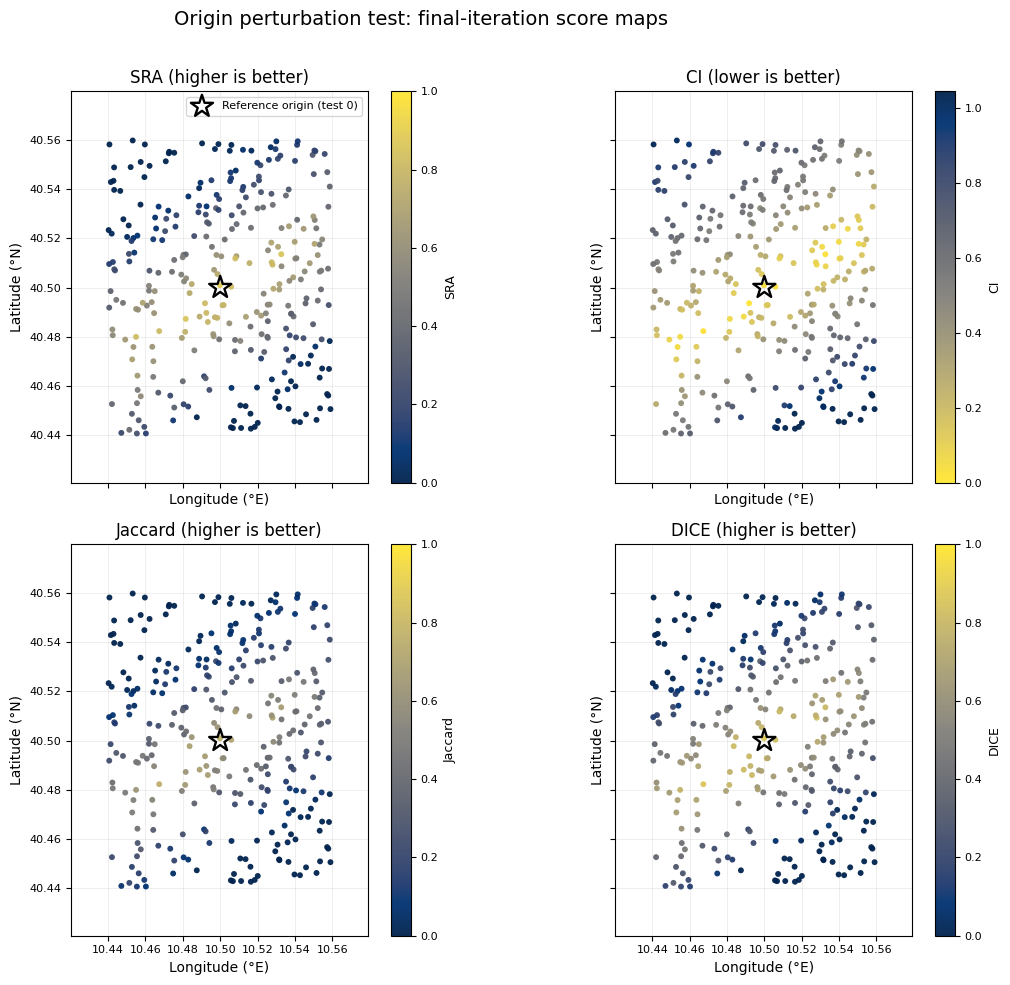

/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_origin_metric_maps.png
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_origin_metric_maps.pdf


In [4]:
import xarray as xr
# function to retrieve u and v from DS
DS = xr.open_dataset('HECO_TEST.nc')

def vectors_from_DS(lon,lat, timedate):
    u = DS.uo.sel(latitude=lat, longitude=lon, time=timedate, method='nearest')
    v = DS.vo.sel(latitude=lat, longitude=lon, time=timedate, method='nearest')

    return u,v

# TODO find the nearest time step 
# target_time = [] #read from yaml file
# ds_plot = DS.sel(time=target_time, method='nearest')
# time_step = ds_plot.time
#
# vector colorbar with custom position outside the map, left-aligned 

# Plot vectors
# convert from m/s to knots
# current_uo = ds_plot.uo.values * 1.94384
# current_vo = ds_plot.vo.values * 1.94384

# magnitude = np.sqrt(current_uo**2 + current_vo**2)
# quiver = ax.quiver(
#     ds_plot.longitude.values, 
#     ds_plot.latitude.values,
#     current_uo, 
#     current_vo,
#     magnitude,  #magnitude color value
#     scale=15,
#     width=0.002,
#     cmap='plasma',  # 'plasma', 'inferno', 'turbo'
#     alpha=0.8,
#     transform=ccrs.PlateCarree()
# )

# # vector colorbar with custom position outside the map, left-aligned 
# cax = inset_axes(ax, 
#                 width="35%",     
#                 height="4%",    
#                 loc='lower left', 
#                 bbox_to_anchor=(0.05, -0.11, 1, 1),  # (x, y, width, height)
#                 bbox_transform=ax.transAxes)
# # draw white box on cax
# cax.set_facecolor('white')
# cax.set_alpha(1)

# cbar = plt.colorbar(quiver, cax=cax, orientation='horizontal')

# cbar.set_label('Currents velocity (knots)', rotation=0, labelpad=10, fontsize=10)
# cbar.ax.tick_params(labelsize=9)
# cbar.outline.set_linewidth(1)
# cbar.outline.set_edgecolor('black')

# cbar.fancybox = True
# cbar.shadow = True

padding = 0.02
extent = (
    float(origin_data["lon"].min() - padding),
    float(origin_data["lon"].max() + padding),
    float(origin_data["lat"].min() - padding),
    float(origin_data["lat"].max() + padding),
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle("Origin perturbation test: final-iteration score maps", fontsize=14)

for ax, metric in zip(axes.flat, METRICS):
    points = draw_metric_panel(ax, origin_data, metric, extent, benchmark_origin)
    colorbar = fig.colorbar(points, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(metric, fontsize=9)
    colorbar.ax.tick_params(labelsize=8)

axes[0, 0].legend(loc="best", frameon=True, fontsize=8)
fig.tight_layout(rect=(0, 0, 1, 0.97))

generated_paths = save_figure(fig, "sa_2_3_origin_metric_maps")
plt.show()
plt.close(fig)

for path in generated_paths:
    print(path)


Requested forcing time: 2025-03-08 00:00:00
Selected forcing time:  2025-03-08 00:00:00


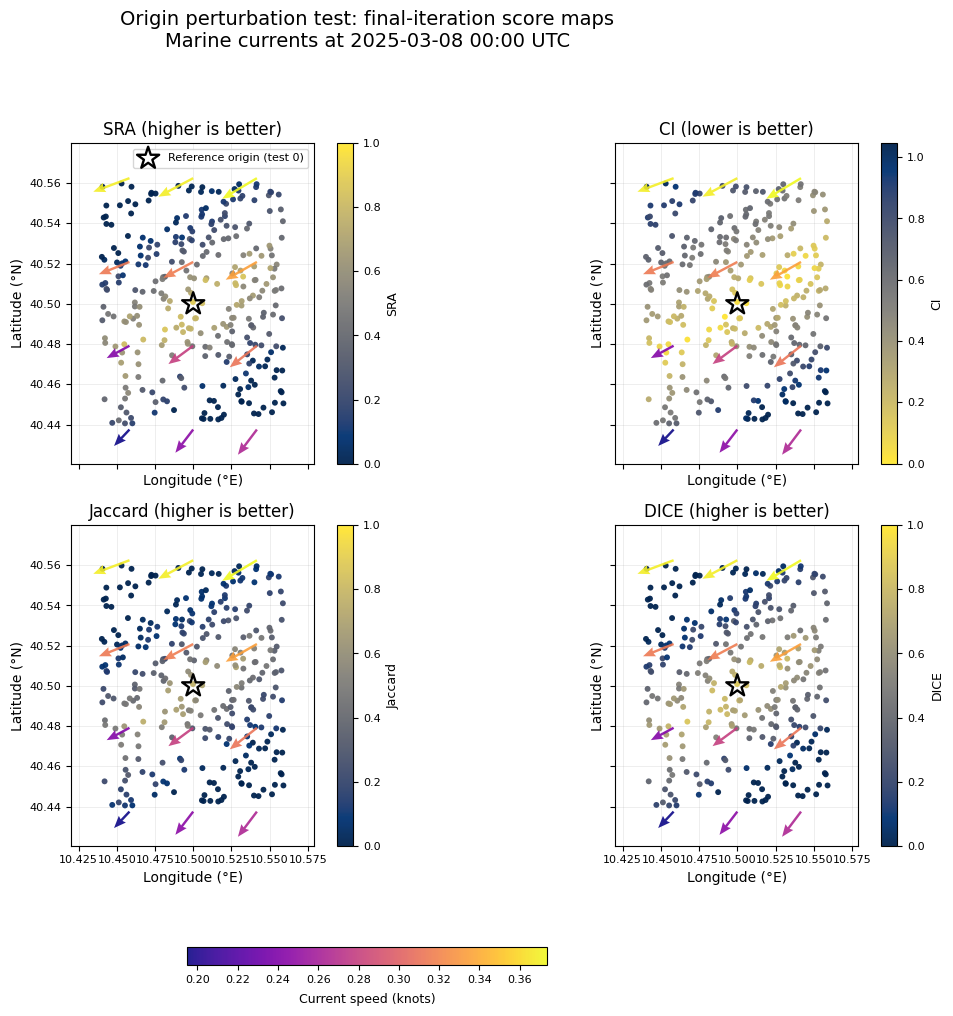

/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_origin_metric_maps_with_currents.png
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_origin_metric_maps_with_currents.pdf


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import yaml


def vectors_from_ds(ds, lon, lat, time_value):
    """Return the nearest current components at one location and time."""
    selected = ds[["uo", "vo"]].sel(
        latitude=lat,
        longitude=lon,
        time=time_value,
        method="nearest",
    )
    return float(selected["uo"]), float(selected["vo"])


def load_current_field(
    forcing_path,
    time_value,
    extent,
    stride=1,
    conversion_factor=1.943844,
):
    """Load the current field nearest to time_value within the plot extent."""
    west, east, south, north = extent

    with xr.open_dataset(forcing_path) as ds:
        ds_time = ds[["uo", "vo"]].sel(
            time=pd.Timestamp(time_value),
            method="nearest",
        )

        # Select only the geographical area represented by the metric maps.
        ds_plot = ds_time.where(
            (ds_time.longitude >= west)
            & (ds_time.longitude <= east)
            & (ds_time.latitude >= south)
            & (ds_time.latitude <= north),
            drop=True,
        )

        if ds_plot.longitude.size == 0 or ds_plot.latitude.size == 0:
            raise ValueError(
                "No forcing-grid points were found inside the plotting extent."
            )

        ds_plot = ds_plot.isel(
            longitude=slice(None, None, stride),
            latitude=slice(None, None, stride),
        ).load()

    # Convert m s-1 to knots.
    current_u = ds_plot["uo"].squeeze(drop=True).values * conversion_factor
    current_v = ds_plot["vo"].squeeze(drop=True).values * conversion_factor
    current_speed = np.hypot(current_u, current_v)

    longitude_grid, latitude_grid = np.meshgrid(
        ds_plot.longitude.values,
        ds_plot.latitude.values,
        indexing="xy",
    )

    selected_time = pd.Timestamp(ds_plot.time.values)

    return {
        "longitude": longitude_grid,
        "latitude": latitude_grid,
        "u": current_u,
        "v": current_v,
        "speed": current_speed,
        "time": selected_time,
    }


# ------------------------------------------------------------------
# Read the reference simulation time and forcing filename from YAML
# ------------------------------------------------------------------

benchmark_yaml_path = (
    sensitivity_dir
    / "sa_2_3"
    / "input_yaml_files"
    / "sa_2_3_test_0.yaml"
)

with benchmark_yaml_path.open("r", encoding="utf-8") as handle:
    benchmark_config = yaml.safe_load(handle)

input_config = benchmark_config["input"]

target_time = pd.Timestamp(input_config["time0"])
forcing_path = sensitivity_dir / input_config["dataset_file_name"]

if not forcing_path.exists():
    raise FileNotFoundError(f"Forcing dataset not found: {forcing_path}")


# ------------------------------------------------------------------
# Define the map extent from the perturbed origins
# ------------------------------------------------------------------

padding = 0.02

extent = (
    float(origin_data["lon"].min() - padding),
    float(origin_data["lon"].max() + padding),
    float(origin_data["lat"].min() - padding),
    float(origin_data["lat"].max() + padding),
)


# ------------------------------------------------------------------
# Retrieve the nearest current field
# ------------------------------------------------------------------

currents = load_current_field(
    forcing_path=forcing_path,
    time_value=target_time,
    extent=extent,
    stride=1,
)

print(f"Requested forcing time: {target_time}")
print(f"Selected forcing time:  {currents['time']}")


# ------------------------------------------------------------------
# Generate the four-panel metric map
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

selected_time_label = currents["time"].strftime("%Y-%m-%d %H:%M UTC")

fig.suptitle(
    "Origin perturbation test: final-iteration score maps\n"
    f"Marine currents at {selected_time_label}",
    fontsize=14,
    y=0.99,
)

current_quiver = None

for ax, metric in zip(axes.flat, METRICS):
    # Plot origin points colored by the selected validation metric.
    points = draw_metric_panel(
        ax=ax,
        data=origin_data,
        metric=metric,
        extent=extent,
        benchmark_origin=benchmark_origin,
    )

    metric_colorbar = fig.colorbar(
        points,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )
    metric_colorbar.set_label(metric, fontsize=9)
    metric_colorbar.ax.tick_params(labelsize=8)

    # Plot currents. A Cartopy transform is not used because these are
    # standard Matplotlib longitude-latitude axes.
    current_quiver = ax.quiver(
        currents["longitude"],
        currents["latitude"],
        currents["u"],
        currents["v"],
        currents["speed"],
        cmap="plasma",
        angles="xy",
        scale_units="xy",
        scale=15,
        width=0.010,
        headwidth=4,
        headlength=5,
        alpha=0.90,
        zorder=3,
    )

axes[0, 0].legend(
    loc="best",
    frameon=True,
    fontsize=8,
)

# Reserve space below the panels for one shared current-speed colorbar.
fig.tight_layout(rect=(0, 0.10, 1, 0.95))

current_colorbar_axis = fig.add_axes(
    [0.35, 0.035, 0.30, 0.018]
)

current_colorbar = fig.colorbar(
    current_quiver,
    cax=current_colorbar_axis,
    orientation="horizontal",
)

current_colorbar.set_label(
    "Current speed (knots)",
    fontsize=9,
    labelpad=6,
)
current_colorbar.ax.tick_params(labelsize=8)


# ------------------------------------------------------------------
# Save and display
# ------------------------------------------------------------------

generated_paths = save_figure(
    fig,
    "sa_2_3_origin_metric_maps_with_currents",
)

plt.show()
plt.close(fig)

for path in generated_paths:
    print(path)


    ## TODO: togliere colori dai vettori usare dimensione
    # mettere contour lines dei risultati...
    # scala cromatica dei punti (blu: corretto, fucsia errato)

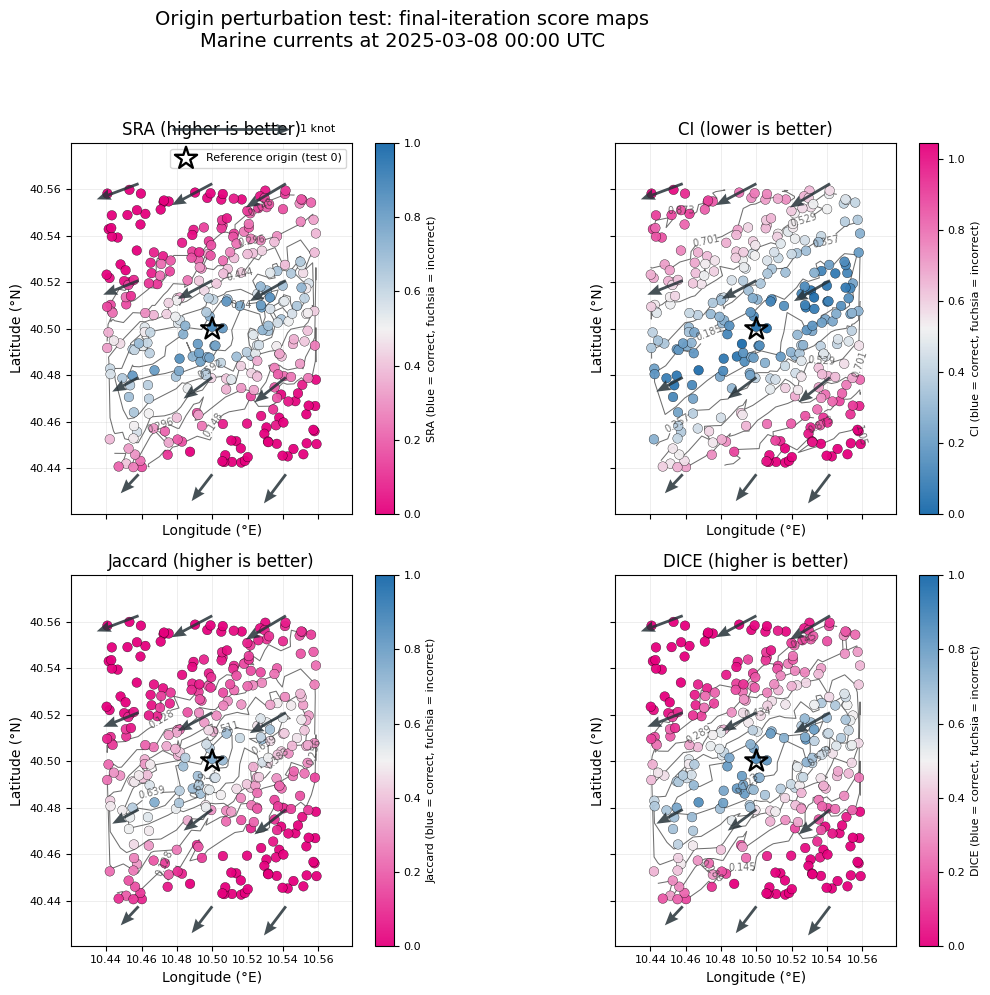

/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_origin_metric_maps_with_currents.png
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_origin_metric_maps_with_currents.pdf


In [6]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


# The first colour means an incorrect result; the last means a correct one.
# The order is reversed automatically for metrics where lower values are better.
BAD_RESULT = "#e5007d"       # fuchsia
GOOD_RESULT = "#1769aa"      # blue
RESULT_CMAP = LinearSegmentedColormap.from_list(
    "bad_to_good",
    [BAD_RESULT, "#f2f2f2", GOOD_RESULT],
)


def metric_result_cmap(metric):
    """Return a blue=good/fuchsia=bad map for the selected metric."""
    higher_is_better = metric != "CI"
    return RESULT_CMAP if higher_is_better else RESULT_CMAP.reversed()


def add_metric_contours(ax, data, metric, finite, vmin, vmax, n_levels=7):
    """Overlay metric isolines on an irregular longitude/latitude point set."""
    x = data.loc[finite, "lon"].to_numpy(dtype=float)
    y = data.loc[finite, "lat"].to_numpy(dtype=float)
    z = data.loc[finite, metric].to_numpy(dtype=float)

    # tricontour needs at least three distinct, non-collinear points.
    coordinates = np.column_stack((x, y))
    _, unique_indices = np.unique(coordinates, axis=0, return_index=True)
    if unique_indices.size < 3 or np.ptp(z) == 0:
        return None

    lower = max(float(vmin), float(np.nanmin(z)))
    upper = min(float(vmax), float(np.nanmax(z)))
    if not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
        return None

    levels = np.linspace(lower, upper, n_levels)
    try:
        contours = ax.tricontour(
            x,
            y,
            z,
            levels=levels,
            colors="0.20",
            linewidths=0.75,
            alpha=0.70,
            zorder=2,
        )
    except (ValueError, RuntimeError):
        # A degenerate perturbation layout can be unsuitable for triangulation.
        return None

    ax.clabel(
        contours,
        inline=True,
        inline_spacing=2,
        fontsize=7,
        fmt="%.3g",
    )
    return contours


def draw_metric_panel(ax, data, metric, extent, benchmark_origin):
    settings = METRICS[metric]
    values = data[metric].to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        raise ValueError(f"Metric '{metric}' contains no finite values")

    if metric == "CI":
        vmax = max(float(np.nanpercentile(values[finite], 95)), 1e-6)
    else:
        vmax = settings["vmax"]
    vmin = settings["vmin"]

    add_metric_contours(
        ax=ax,
        data=data,
        metric=metric,
        finite=finite,
        vmin=vmin,
        vmax=vmax,
    )

    points = ax.scatter(
        data.loc[finite, "lon"],
        data.loc[finite, "lat"],
        c=data.loc[finite, metric],
        cmap=metric_result_cmap(metric),
        vmin=vmin,
        vmax=vmax,
        s=48,
        edgecolors="black",
        linewidths=0.25,
        alpha=0.95,
        zorder=3,
    )
    ax.scatter(
        benchmark_origin[1],
        benchmark_origin[0],
        marker="*",
        s=280,
        facecolors="none",
        edgecolors="black",
        linewidths=1.7,
        label="Reference origin (test 0)",
        zorder=5,
    )
    ax.set(
        xlim=extent[:2],
        ylim=extent[2:],
        xlabel="Longitude (°E)",
        ylabel="Latitude (°N)",
        title=f"{metric} ({settings['description']})",
    )
    mean_latitude = float(data["lat"].mean())
    ax.set_aspect(1 / np.cos(np.deg2rad(mean_latitude)))
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.tick_params(labelsize=8)
    return points


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
)

selected_time_label = currents["time"].strftime("%Y-%m-%d %H:%M UTC")

fig.suptitle(
    "Origin perturbation test: final-iteration score maps\n"
    f"Marine currents at {selected_time_label}",
    fontsize=14,
    y=0.99,
)

first_current_quiver = None

for panel_index, (ax, metric) in enumerate(zip(axes.flat, METRICS)):
    points = draw_metric_panel(
        ax=ax,
        data=origin_data,
        metric=metric,
        extent=extent,
        benchmark_origin=benchmark_origin,
    )

    metric_colorbar = fig.colorbar(
        points,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )
    metric_colorbar.set_label(
        f"{metric} (blue = correct, fuchsia = incorrect)",
        fontsize=8,
    )
    metric_colorbar.ax.tick_params(labelsize=8)

    # One neutral colour: current speed is encoded by arrow length, not colour.
    quiver = ax.quiver(
        currents["longitude"],
        currents["latitude"],
        currents["u"],
        currents["v"],
        color="#263238",
        angles="xy",
        scale_units="xy",
        scale=15,
        width=0.010,
        headwidth=4,
        headlength=5,
        alpha=0.85,
        zorder=4,
    )
    if panel_index == 0:
        first_current_quiver = quiver

axes[0, 0].legend(
    loc="best",
    frameon=True,
    fontsize=8,
)

if first_current_quiver is not None:
    axes[0, 0].quiverkey(
        first_current_quiver,
        X=0.78,
        Y=1.04,
        U=1.0,
        label="1 knot",
        labelpos="E",
        coordinates="axes",
        color="#263238",
        fontproperties={"size": 8},
    )

fig.tight_layout(rect=(0, 0, 1, 0.95))

generated_paths = save_figure(
    fig,
    "sa_2_3_origin_metric_maps_with_currents",
)

plt.show()
plt.close(fig)

for path in generated_paths:
    print(path)

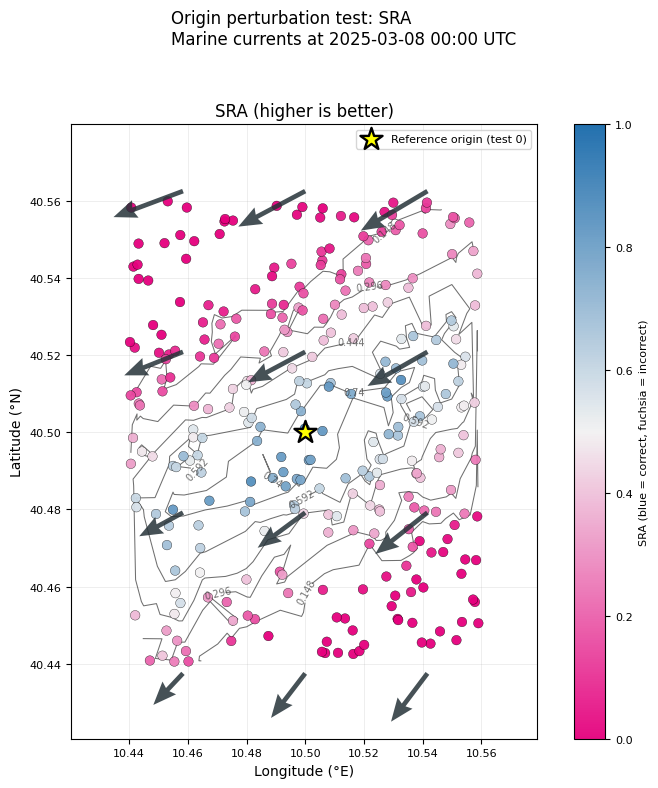

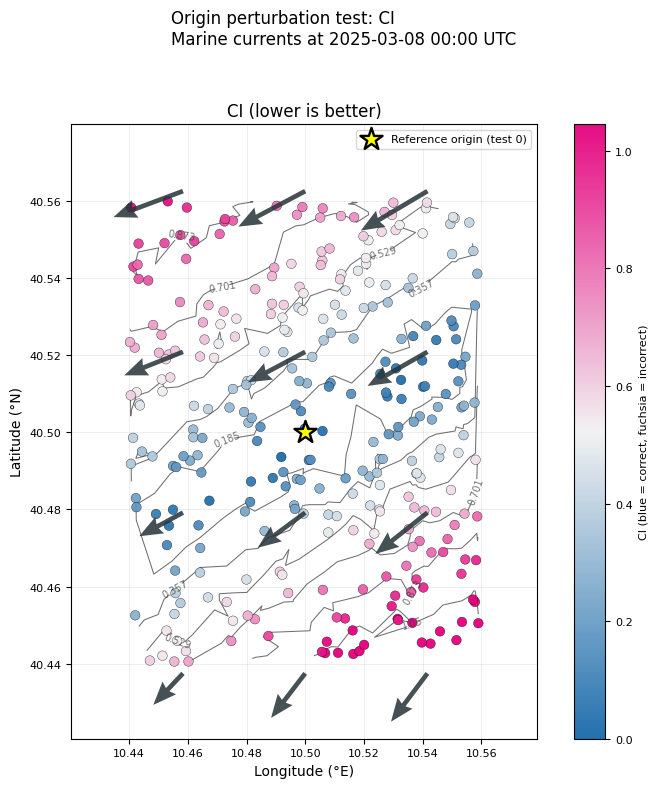

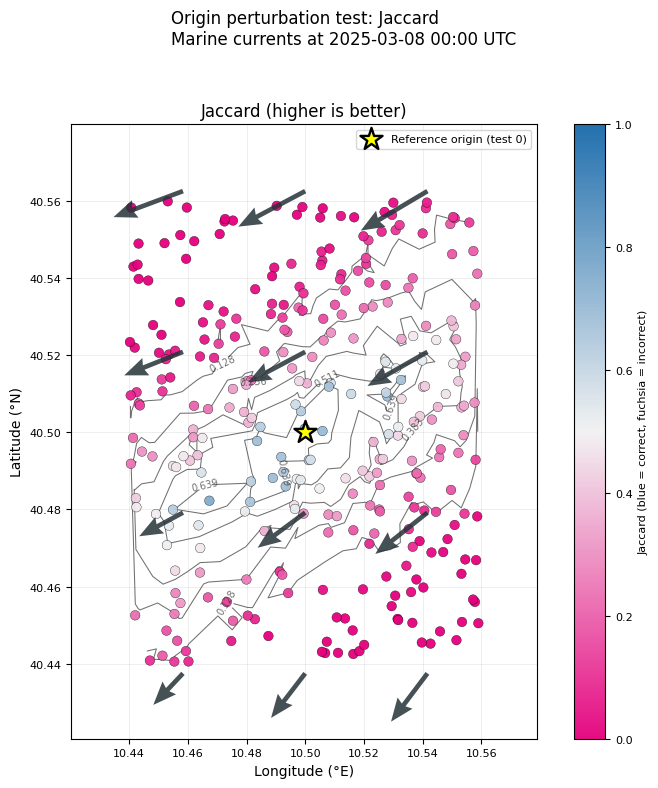

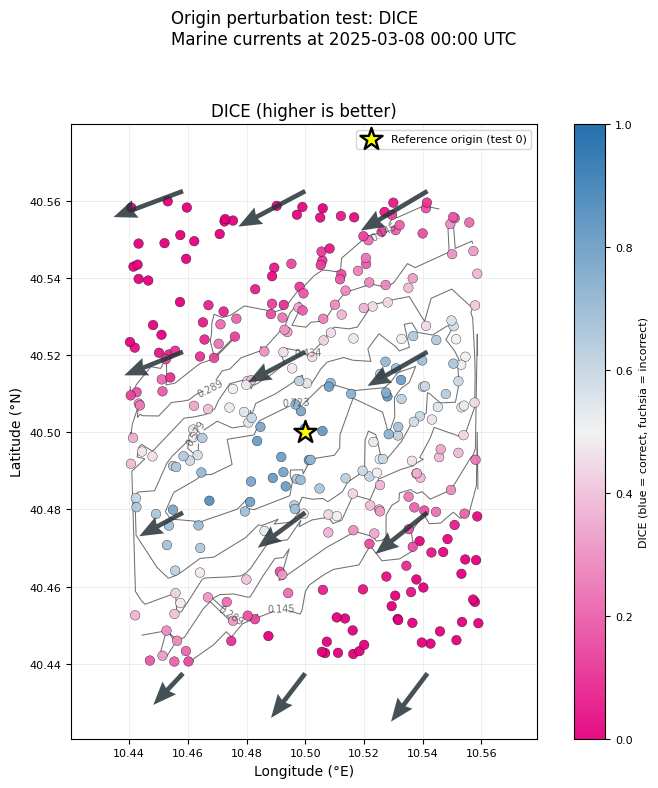

/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_sra_origin_metric_map_with_currents.png
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_sra_origin_metric_map_with_currents.pdf
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_ci_origin_metric_map_with_currents.png
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_ci_origin_metric_map_with_currents.pdf
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_jaccard_origin_metric_map_with_currents.png
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_jaccard_origin_metric_map_with_currents.pdf
/Volumes/LaCie/000 - Dottorato UNICT/seaquest_team/HECO/heco/sensivity_analysis/figures_sensitivity/sa_2_3_dice_

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


# The first colour means an incorrect result; the last means a correct one.
# The order is reversed automatically for metrics where lower values are better.
BAD_RESULT = "#e5007d"       # fuchsia
GOOD_RESULT = "#1769aa"      # blue
RESULT_CMAP = LinearSegmentedColormap.from_list(
    "bad_to_good",
    [BAD_RESULT, "#f2f2f2", GOOD_RESULT],
)


def metric_result_cmap(metric):
    """Return a blue=good/fuchsia=bad map for the selected metric."""
    higher_is_better = metric != "CI"
    return RESULT_CMAP if higher_is_better else RESULT_CMAP.reversed()

def add_metric_contours(ax, data, metric, finite, vmin, vmax, n_levels=7):
    """Overlay metric isolines on an irregular longitude/latitude point set."""
    x = data.loc[finite, "lon"].to_numpy(dtype=float)
    y = data.loc[finite, "lat"].to_numpy(dtype=float)
    z = data.loc[finite, metric].to_numpy(dtype=float)

    # tricontour needs at least three distinct, non-collinear points.
    coordinates = np.column_stack((x, y))
    _, unique_indices = np.unique(coordinates, axis=0, return_index=True)
    if unique_indices.size < 3 or np.ptp(z) == 0:
        return None

    lower = max(float(vmin), float(np.nanmin(z)))
    upper = min(float(vmax), float(np.nanmax(z)))
    if not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
        return None

    levels = np.linspace(lower, upper, n_levels)
    try:
        contours = ax.tricontour(
            x,
            y,
            z,
            levels=levels,
            colors="0.20",
            linewidths=0.75,
            alpha=0.70,
            zorder=2,
        )
    except (ValueError, RuntimeError):
        # A degenerate perturbation layout can be unsuitable for triangulation.
        return None

    ax.clabel(
        contours,
        inline=True,
        inline_spacing=2,
        fontsize=7,
        fmt="%.3g",
    )
    return contours


def draw_metric_panel(ax, data, metric, extent, benchmark_origin):
    settings = METRICS[metric]
    values = data[metric].to_numpy(dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        raise ValueError(f"Metric '{metric}' contains no finite values")

    if metric == "CI":
        vmax = max(float(np.nanpercentile(values[finite], 95)), 1e-6)
    else:
        vmax = settings["vmax"]
    vmin = settings["vmin"]

    add_metric_contours(
        ax=ax,
        data=data,
        metric=metric,
        finite=finite,
        vmin=vmin,
        vmax=vmax,
    )

    points = ax.scatter(
        data.loc[finite, "lon"],
        data.loc[finite, "lat"],
        c=data.loc[finite, metric],
        cmap=metric_result_cmap(metric),
        vmin=vmin,
        vmax=vmax,
        s=48,
        edgecolors="black",
        linewidths=0.25,
        alpha=0.95,
        zorder=3,
    )
    ax.scatter(
        benchmark_origin[1],
        benchmark_origin[0],
        marker="*",
        s=280,
        facecolors="yellow",
        edgecolors="black",
        linewidths=1.7,
        label="Reference origin (test 0)",
        zorder=5,
    )
    ax.set(
        xlim=extent[:2],
        ylim=extent[2:],
        xlabel="Longitude (°E)",
        ylabel="Latitude (°N)",
        title=f"{metric} ({settings['description']})",
    )
    mean_latitude = float(data["lat"].mean())
    ax.set_aspect(1 / np.cos(np.deg2rad(mean_latitude)))
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.tick_params(labelsize=8)
    return points


selected_time_label = currents["time"].strftime("%Y-%m-%d %H:%M UTC")
generated_paths = []

# Create one independent figure per metric instead of a 2x2 subplot grid.
for metric in METRICS:
    fig, ax = plt.subplots(figsize=(10, 8))

   
    fig.suptitle(
        f"Origin perturbation test: {metric}\n"
        f"Marine currents at {selected_time_label}",
        fontsize=12,
        x = 0.5,
        ha='left'
    )

    points = draw_metric_panel(
        ax=ax,
        data=origin_data,
        metric=metric,
        extent=extent,
        benchmark_origin=benchmark_origin,
    )

    metric_colorbar = fig.colorbar(
        points,
        ax=ax,
        fraction=0.050,
        pad=0.04,
    )
    metric_colorbar.set_label(
        f"{metric} (blue = correct, fuchsia = incorrect)",
        fontsize=8,
    )
    metric_colorbar.ax.tick_params(labelsize=8)

    # One neutral colour: current speed is encoded by arrow length, not colour.
    quiver = ax.quiver(
        currents["longitude"],
        currents["latitude"],
        currents["u"],
        currents["v"],
        color="#263238",
        angles="xy",
        scale_units="xy",
        scale=15,
        width=0.010,
        headwidth=4,
        headlength=5,
        alpha=0.85,
        zorder=4,
    )

    ax.legend(
        loc="best",
        frameon=True,
        fontsize=8,
    )
    # ax.quiverkey(
    #     quiver,
    #     X=0.78,
    #     Y=1.04,
    #     U=1.0,
    #     label="1 knot",
    #     labelpos="E",
    #     coordinates="axes",
    #     color="#263238",
    #     fontproperties={"size": 8},
    # )

    fig.tight_layout(rect=(0, 0, 1, 0.95))

    # Keep filenames filesystem-safe while preserving the metric name in them.
    metric_stem = "".join(
        character.lower() if character.isalnum() else "_"
        for character in metric
    ).strip("_")
    generated_paths.extend(
        save_figure(
            fig,
            f"sa_2_3_{metric_stem}_origin_metric_map_with_currents",
        )
    )

    plt.show()
    plt.close(fig)

for path in generated_paths:
    print(path)


# trasformare le contour in shade con gli stessi colori dell'intervallo
# -> iDw (evidenziare la regione di correttezza)